# Classification Agreement Evaluator
I briefly changed Julia's binary_eval to suit my improved binary_classifier program, before completely incorporating it into the program itself, so this has not been used for any results. Furthermore, the entire concept is redundant since the true value can be obtained via simple majority instead of this whole program.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from collections import defaultdict
from functools import reduce
import pickle
from pathlib import Path

### Read in Data

In [10]:
ITERATION = "Test1_it1"

PREDICTION_DIR = (
    f"/pscratch/sd/q/qshimp/Sorter/binary_results/{ITERATION}"
)

ANCHORS_DIR = "/pscratch/sd/q/qshimp/Sorter/sga2025_1000test_with_anchors.csv"

GALAXY_TYPES = {
    "spiral": {
        "index": 10,
        "color": "olive",
    },
    "elliptical": {
        "index": 20,
        "color": "sienna",
    },
    "lenticular": {
        "index": 0,
        "color": "cornflowerblue",
    },
    "irregular": {
        "index": -5,
        "color": "salmon",
    },
}

prediction_files = {
    name: (
        f"{PREDICTION_DIR}/"
        f"{ITERATION}_predictions_{name}.csv"
    )
    for name in GALAXY_TYPES
}

predictions = {
    name: pd.read_csv(path)
    for name, path in prediction_files.items()
}

anchors = pd.read_csv(ANCHORS_DIR)
anchors = anchors.rename(columns={"ref_id": "Target_ID"})

previous_anchors = {
    "spiral": anchors.loc[
        anchors["Main_type"] == 10,
        "Target_ID"
    ].tolist(),

    "elliptical": anchors.loc[
        anchors["Main_type"] == 20,
        "Target_ID"
    ].tolist(),

    "lenticular": anchors.loc[
        anchors["Main_type"] == 0,
        "Target_ID"
    ].tolist(),

    "irregular": anchors.loc[
        anchors["Main_type"] == -5,
        "Target_ID"
    ].tolist(),
}

print("Loaded previous anchors:")
for name, ids in previous_anchors.items():
    print(f"{name.capitalize():12}: {len(ids):6d}")

Loaded previous anchors:
Spiral      :   1000
Elliptical  :   1000
Lenticular  :   1000
Irregular   :   1000


### Clean up DataFrames

In [3]:
for name, df in predictions.items():

    ndups = df.duplicated("Target_ID").sum()

    print(f"{name.capitalize():12}: {ndups} duplicates")

    predictions[name] = df.drop_duplicates("Target_ID")

# Rename columns to avoid conflicts
for name, df in predictions.items():

    df.rename(
        columns={
            "Predicted_Label": f"{name}_binary",
            "Predicted_Type": f"{name}_prediction",
        },
        inplace=True,
    )

Spiral      : 0 duplicates
Elliptical  : 0 duplicates
Lenticular  : 0 duplicates
Irregular   : 0 duplicates


In [4]:
for name, df in predictions.items():
    predictions[name] = df.rename(columns={"Prediction": f"{name}_prediction"})

# Merge all DataFrames on 'Target_ID'
merged = reduce(lambda left, right: left.merge(right, on="Target_ID"), predictions.values(),)

classified = {}

for name in GALAXY_TYPES:
    pred_col = f"{name}_prediction"
    classified[name] = merged[merged[pred_col] == name.title()]

print("\nPredicted galaxies")

for name, df in classified.items():
    print(f"{name.capitalize():12}: {len(df):6d}")


Predicted galaxies
Spiral      :    330
Elliptical  :    213
Lenticular  :     56
Irregular   :    146


### Binary Evaluation Historgram

In [5]:
# Define a function to classify the number of agreements
AGREEMENT_TYPES = [
    "Crying",
    "Weak Agreement",
    "Partial Agreement",
    "Agreement",
    "No Classification",
]

def add_agreement_labels(df):

    prediction_columns = [
        f"{name}_prediction"
        for name in GALAXY_TYPES
    ]

    df = df.copy()

    df["n_other"] = (
        df[prediction_columns]
        .eq("Other")
        .sum(axis=1)
    )

    df["Consensus"] = df["n_other"].map(
        dict(enumerate(AGREEMENT_TYPES))
    )

    df["Consensus"] = pd.Categorical(
        df["Consensus"],
        categories=AGREEMENT_TYPES,
        ordered=True,
    )

    return df


def plot_agreement_histogram(df, color="#f07a9c"):

    counts = (
        df["Consensus"]
        .value_counts()
        .reindex(AGREEMENT_TYPES)
        .fillna(0)
        .astype(int)
    )

    plt.figure(figsize=(12, 7))

    bars = counts.plot(
        kind="bar",
        color=color,
        edgecolor="black",
    )

    plt.title("Classifier Agreement")
    plt.xlabel("Agreement")
    plt.ylabel("Galaxies")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    for bar in bars.patches:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(1, counts.max() * 0.005),
            int(bar.get_height()),
            ha="center",
        )

    plt.tight_layout()
    plt.show()

    return counts

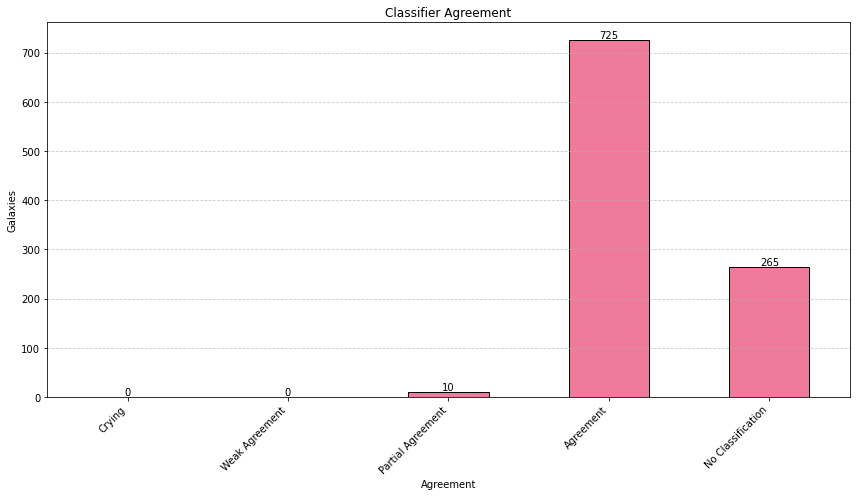

In [6]:
merged = add_agreement_labels(merged)
counts = plot_agreement_histogram(merged)

In [7]:
# Separate reruns from accepted classifications

rerun_categories = [
    "No Classification",
    "Partial Agreement",
    "Weak Agreement",
]

rerun = merged[merged["Consensus"].isin(rerun_categories)]

rerun_ids = rerun["Target_ID"].tolist()
rerun_set = set(rerun_ids)

print("\nGalaxies requiring another iteration")

for category in rerun_categories:
    n = (merged["Consensus"] == category).sum()
    print(f"{category:20}: {n}")

print(f"\nTotal reruns: {len(rerun_ids)}")

# Remove rerun galaxies from each accepted class
for name in classified:

    classified[name] = classified[name][
        ~classified[name]["Target_ID"].isin(rerun_set)
    ]

classified_ids = {
    name: df["Target_ID"].tolist()
    for name, df in classified.items()
}

print("\nAccepted classifications")

for name, ids in classified_ids.items():
    print(f"{name.capitalize():12}: {len(ids):6d}")

print(f"\nTotal accepted: {sum(map(len, classified_ids.values()))}")


Galaxies requiring another iteration
No Classification   : 265
Partial Agreement   : 10
Weak Agreement      : 0

Total reruns: 275

Accepted classifications
Spiral      :    325
Elliptical  :    207
Lenticular  :     51
Irregular   :    142

Total accepted: 725


In [11]:
# Save iteration product

all_anchors = {
    name: list(set(previous_anchors[name] + classified_ids[name]))
    for name in GALAXY_TYPES
}

iteration_product = {
    "iteration": ITERATION,
    "anchors": all_anchors,
    "classified": classified_ids,
    "rerun": rerun,
    "agreement_counts": counts.to_dict(),
    "prediction_files": prediction_files,
    "galaxy_types": GALAXY_TYPES,
}

output_file = Path(PREDICTION_DIR) / f"{ITERATION}.pkl"

with open(output_file, "wb") as f:
    pickle.dump(iteration_product, f)

print(f"Saved {output_file}")

Saved /pscratch/sd/q/qshimp/Sorter/binary_results/Test1_it1/Test1_it1.pkl
